

One group in PRBB has studied a particular protein with the following sequence:

ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDNTQGCTSAGPLFNPLSKK
LGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLLGRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAG
SRLACGVLGLAK

They are not sure about the function of this protein. 
Could you answer the following questions?:

__1) To what PFAM family this protein belongs? (fetch and rename the HMM model as "target29.hmm")__

First of all create a file called `target.fa`and paste the sequence like this:

```
>target
ATKAICILKGDGPVQGTLSSLSLHFEAKGDEGGDTIVITGSLTGLTEGDHGWHIHQWGDNTQGCTSAGPLFNPLSKK
LGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLLGRTMVIHEKPLVLGRGGNEELMIQNSTKKTGNAG
SRLACGVLGLAK
```
Then run `hmmscan`to find the PFAM family the protein belongs to:

`hmmscan /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm target.fa > targetpfam.out`

And we see that this protein belongs to a superoxide dismutase family:

```
Query:       target  [L=166]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model    Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    3.5e-37  127.6   0.1      4e-37  127.4   0.1    1.1  1  Sod_Cu    Copper/zinc superoxide dismutase (SODC)
```
`hmmfetch /mnt/NFS_UPF/soft/databases/pfam-3/Pfam-A.hmm Sod_Cu > target29.hmm`


__2) Please align the sequence of this protein with three different  close homologs, with known structure and different sequences, using the HMM profile. (place the alignment in a file named "align29.txt")__

As it says _close homologs_ I will use `blastp` to find them. Once done, perform a multiple sequence alignment (MSA) using a specific Profile Hidden Markov Model (HMM) as a template. This ensures that the alignment of the target sequence with its homologs is guided by the conserved structural motifs of that protein family. Standard alignments can sometimes fail if the sequence identity is low. The HMM profile contains "knowledge" about which positions in a protein family are highly conserved (like active sites) and which are variable. Aligning to the profile ensures that your target sequence is matched against these important structural landmarks correctly.

- Find homologs --> `hmmsearch` 

    - Known Structure: They must have a 4-character PDB code (e.g., 1z8u).

    - Close Homologs: Look for the lowest E-values (closest to 0.0).

    - Different Sequences: Do not pick three versions of the same protein.

`hmmsearch target29.hmm /mnt/NFS_UPF/soft/databases/blastdat/pdb_seq > target29_pdb.out`

```
Query:       Sod_Cu  [M=142]
Accession:   PF00080.15
Description: Copper/zinc superoxide dismutase (SODC)
Scores for complete sequences (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Sequence Description
    ------- ------ -----    ------- ------ -----   ---- --  -------- -----------
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1cbj_A    mol:protein length:151  PROTEIN (SUPEROXIDE DISMUTA
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1cbj_B    mol:protein length:151  PROTEIN (SUPEROXIDE DISMUTA
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1cob_A    mol:protein length:151  SUPEROXIDE DISMUTASE
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1cob_B    mol:protein length:151  SUPEROXIDE DISMUTASE
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1q0e_A    mol:protein length:151  Superoxide dismutase [Cu-Zn
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1q0e_B    mol:protein length:151  Superoxide dismutase [Cu-Zn
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1sda_B    mol:protein length:151  COPPER,ZINC SUPEROXIDE DISM
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1sda_G    mol:protein length:151  COPPER,ZINC SUPEROXIDE DISM
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1sda_O    mol:protein length:151  COPPER,ZINC SUPEROXIDE DISM
    1.8e-50  173.8   4.6    2.1e-50  173.6   4.6    1.0  1  1sda_Y    mol:protein length:151  COPPER,ZINC SUPEROXIDE DISM
```

As homologs,  ecause they have a really singiifciant e.value, i 'll use `1cbj_A`, `1qoe_A`and `1sda_B`. Now retieve these homologs from the database of the uni:

```
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/cb/pdb1cbj.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/q0/pdb1q0e.ent.gz .
cp /mnt/NFS_UPF/soft/databases/pdb/pdb/data/structures/divided/pdb/sd/pdb1sda.ent.gz .

gunzip *gz

PDBtoSplitChain.pl -i pdb1cbj.ent -o 1cbj_
PDBtoSplitChain.pl -i pdb1q0e.ent -o 1q0e_
PDBtoSplitChain.pl -i pdb1sda.ent -o 1sda_

cat target.fa > alignment.fa
cat 1cbj_A.fa >> alignment.fa 
cat 1q0e_A.fa >> alignment.fa 
cat 1sda_B.fa >> alignment.fa 
```

- Alignment --> `hmmalign`(_align the target with the three homologs file  using the .hmm profile_)

`hmmalign target29.hmm alignment.fa > align29.txt`

And obtain this as a results:

```
# STOCKHOLM 1.0

target         atkaicilkgdgpvqgtlssls---------------LHFEAKGDEGGdtIVITGSLTGLTEGDHGWHIHQWGDN-TQGCTSAGPLFNPLSKKLGGPKDEERVVGDLGNITADKNGVALIDLIDPLLSLSGEYSLLGRTMVIHEKPLVLgrggneelmiqnSTKKTGNAGSRLACGV-lglak
#=GR target PP ***7655555444444444443...............4688888777788************************9.*********************************************************************9988***************************9.6****
1cbj_A         ...................atkAVCVLKG-DGPVQGTIHFEAKG--DT..VVVTGSITGLTEGDHGFHVHQFGDN-TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLgrg......gneESTKTGNAGSRLACGVIgiak.
#=GR 1cbj_A PP ...................***6899996.899***********..66..************************9.****************************************************************************......*******************9****.
1q0e_A         ...................atkAVCVLKG-DGPVQGTIHFEAKG--DT..VVVTGSITGLTEGDHGFHVHQFGDN-TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLSGEYSIIGRTMVVHEKPDDLgrg......gneESTKTGNAGSRLACGVIgiak.
#=GR 1q0e_A PP ...................***6899996.899***********..66..************************9.****************************************************************************......*******************9****.
1sda_B         ...................atkAVCVLKG-DGPVQGTIHFEAKG--DT..VVVTGSITGLTEGDHGFHVHQFGDN-TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIVDIVDPLISLS-GESIIGRTMVVHEKPDDLgrg......gneESTKTGNAGSRLACGVIgiak.
#=GR 1sda_B PP ...................***6899996.899***********..66..************************9.*****************************************************9.77*******************......*******************9****.
#=GC PP_cons   ......................6899996.899****89999997766..************************9.*******************************************************99***************9............***************99.....
#=GC RF        ......................xxxxxxxxxxxxxxxxxxxxxxxxxx..xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx............xxxxxxxxxxxxxxxxx.....
//

```

This produces a Stockton/SELEX formatted alignment where every sequence is matched against the HMM's consensus.


__3) Do you think it will work as any of the closest homologs? (summarize your hypothesis: Show the amino-acids required for the particular function  in the previous sequence alignment with a "@" symbol on the top of the alignment in clustalw format in a file named "align29_function.aln" )__
   Example:
             @
     AAAAAAAAGAAAAAA
     AAAAAAAAAAAAAAA

If you just put the four sequences into ClustalW, it will perform a "de novo" alignment—it looks for similarities between those four specific sequences only.
By using hmmalign, you are using a profile built from thousands of sequences. This ensures that even if your homologs are diverse, the residues are aligned according to the true conserved positions of the protein family.

`esl-reformat clustal align29.txt > align29_function.aln`


As we used hmm to do the alignemtn and will sotre the convserved regions, it is more reliable rather tan jus tuse plain blastp. 

To know the important regions, I will take a look at `interpro` (Pfam web page)  and there I'll paste teh accession number obtained in the `target29_pdb.out` and in the overview section, copy the prosite ID and paste it in the `PROSITE` and it will tell me the most important regions:

_We derived two signature patterns for this family of enzymes: the first one contains two histidine residues that bind the copper atom; the second one is located in the C-terminal section of SODC and contains a cysteine which is involved in a disulfide bond._

If we open on chimer one template, and open the MSA, we will see the important residues interacting with the ions and also it's position to put the "@" in the `target29_pdb.out`.

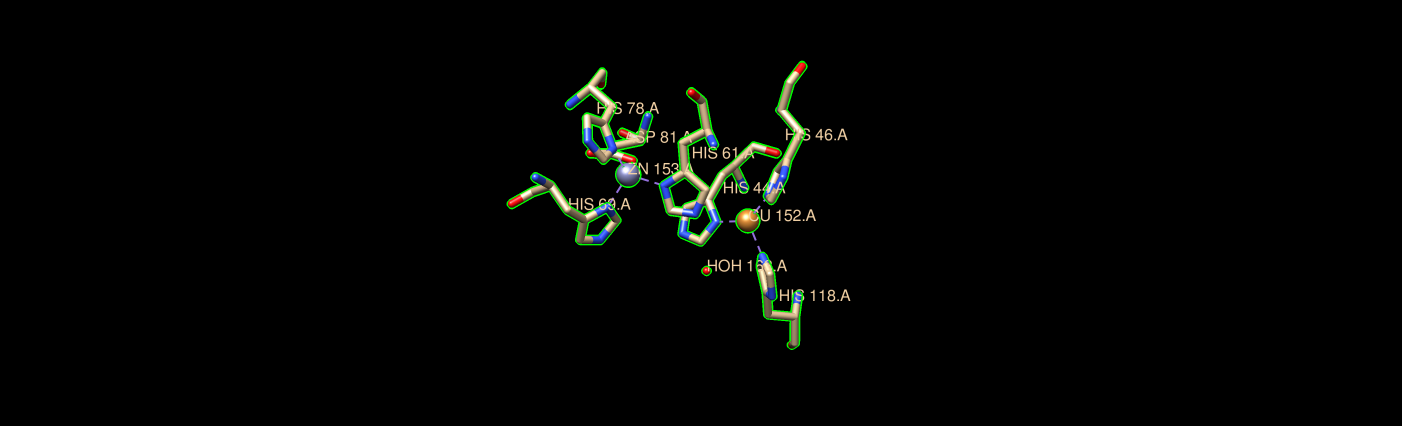

```
target atkaicilkgdgpvqgtlssls---------------LHFEAKGDEGGdtIVITGSLTGL
1cbj_A ...................atkAVCVLKG-DGPVQGTIHFEAKG--DT..VVVTGSITGL
1q0e_A ...................atkAVCVLKG-DGPVQGTIHFEAKG--DT..VVVTGSITGL
1sda_B ...................atkAVCVLKG-DGPVQGTIHFEAKG--DT..VVVTGSITGL
                                             ******       * *** ***
              @ @               @       @        @  @ 
target TEGDHGWHIHQWGDN-TQGCTSAGPLFNPLSKKLGGPKDEERVVGDLGNITADKNGVALI
1cbj_A TEGDHGFHVHQFGDN-TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIV
1q0e_A TEGDHGFHVHQFGDN-TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIV
1sda_B TEGDHGFHVHQFGDN-TQGCTSAGPHFNPLSKKHGGPKDEERHVGDLGNVTADKNGVAIV
       ****** * ** *** ********* ******* ******** ****** ********  
                             @ 
target DLIDPLLSLSGEYSLLGRTMVIHEKPLVLgrggneelmiqnSTKKTGNAGSRLACGV-lg
1cbj_A DIVDPLISLSGEYSIIGRTMVVHEKPDDLgrg......gneESTKTGNAGSRLACGVIgi
1q0e_A DIVDPLISLSGEYSIIGRTMVVHEKPDDLgrg......gneESTKTGNAGSRLACGVIgi
1sda_B DIVDPLISLS-GESIIGRTMVVHEKPDDLgrg......gneESTKTGNAGSRLACGVIgi
       *  *** ***   *  ***** ****  ****            *************   
```
As shown, the target does not have His61, His69 and His78 and those are important for zn interaction. Therefore, it will NOT work as a standard Cu/Zn Superoxide Dismutase. His have + charges, while L and V are hydrophobic aminoacids, so the activity of the aa is not conserved, therefore, the target has lost its funciton to interact with the zn ion!!!



__Build the the structure of this protein by homolgy modelling.__

__4) What's the fold of this protein?__

To know the fold of the protein, we have to look at SCOP the PDB code of the best match of the target sequence. SCOP does not classify the proteins by its family (like Pfam does), but it does by its 3D structure. The best homolog for the target protein is `1cbj_A` as we obtained. In SCOP there's no results for 1cbj_A, but for a close honolog yes and it says SOD1 (Superoxide Dismutase) proteins belong to the _"Immunoglobulin-like beta-sandwich" fold._



__5) Superpose the structure of your model with one member of the same fold  (as for example one of the templates), name the file p29_fig1_superpose.pdb  and show a picture in ribbons of the superimposition in p29_fig1.jpg showing the location of heteroatoms (except water). What's the RMSD  of the CA atoms? (save the file as  p29_RMSca_superpose.txt)__

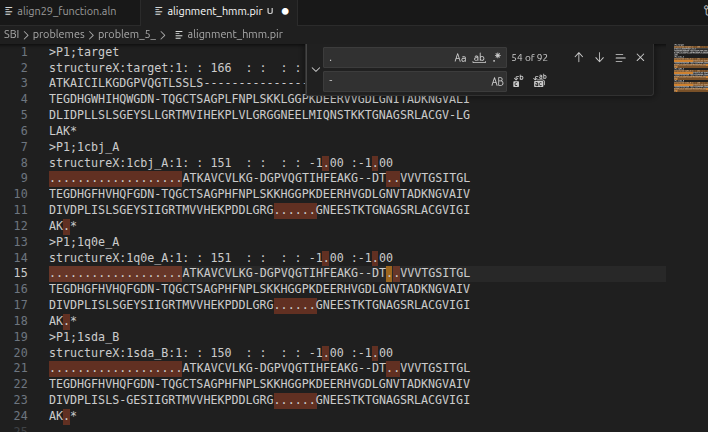

Will pick the one that has higher scores, whch is the first one. Open `chimera target.B99990001.pdb pdb1cbj.ent ` to see the heteroatonms (cu and zn):

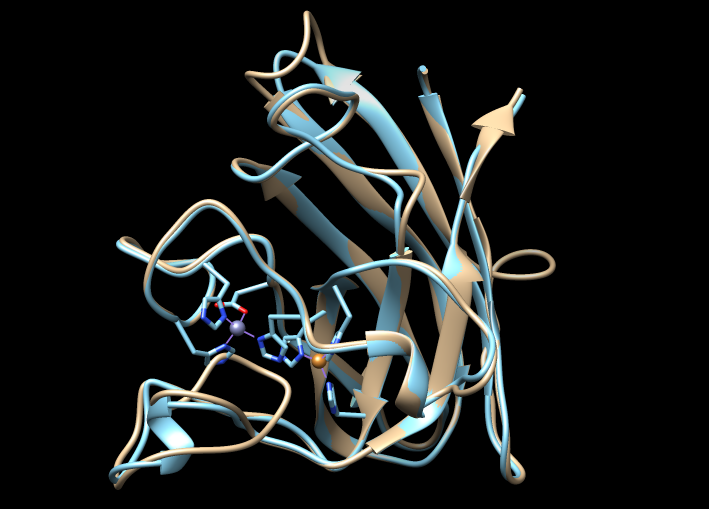

To __calculate the RMSD for the _CA_ atoms on chimera first superpose the structures on `matchmaker`> `favourites`>`replylog`:

```
Model 0 (target.B99990001.pdb) appears to be a protein without secondary structure assignments.
Automatically computing assignments using 'ksdssp' and parameter values:
  energy cutoff -0.5
  minimum helix length 3
  minimum strand length 3
Use command 'help ksdssp' for more information.
#1, chain A: superoxide dismutase
#1, chain B: superoxide dismutase
Computing secondary structure assignments for model(s) #0, #1
using ksdssp (Kabsch and Sander Define Secondary Structure
of Proteins) with the parameters:
  energy cutoff -0.5
  minimum helix length 3
  minimum strand length 3

Matchmaker target.B99990001.pdb (#0) with pdb1cbj.ent, chain A (#1), sequence alignment score = 594
with these parameters:
	chain pairing: bb
	Needleman-Wunsch using BLOSUM-62
	ss fraction: 0.3
	gap open (HH/SS/other) 18/18/6, extend 1
	ss matrix:  (O, S): -6 (H, O): -6 (H, H): 6 (S, S): 6 (H, S): -9 (O, O): 4
	iteration cutoff: 2
RMSD between 120 pruned atom pairs is 0.301 angstroms; (across all 151 pairs: 7.053)

```

_The RMSD will tell us how different are these two proteins structurally._ 

- 0.306 Å (Pruned): This is the RMSD after Chimera "threw out" the parts that didn't align well (like floppy loops) to get the best core fit.

- 7.053 Å (All pairs): This is the RMSD for all 151 Carbon Alpha (CA) atoms.


6) Illustrate a detail with the active site of the enzyme in the previous superposition to reinforce your discussion in question 3 (p29_fig2.jpg) 

7) Compare the energy of knowledge based potentials of Prosa of your model and your template(s) in p29_fig3.jpg (please keep the same colors for target and template as in p29_fig1.jpg or some reference energy_vs_sequence so I can understand your answer)